In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from utils import parse_latencies_trt, parse_power_log, get_power_index, compute_layer_metrics_by_cycle

In [2]:
DATA_PATH = Path('../raw_data/single_conv_layer_trt')

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 3598336.3484432343


## Single Convolution Layers


### Kernel 1 Stride 1 Output 3

In [4]:
model_name = 'conv_k1_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 33.71it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o3: 16193
Number of TensorRT layers in conv_k1_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.511642 seconds


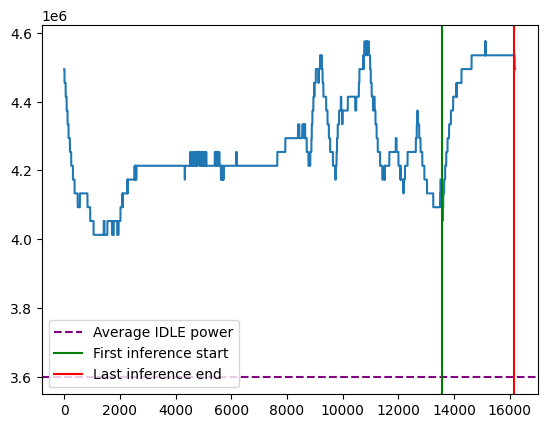

In [6]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[len(latency_data)-1][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [7]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k1 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 742179.54it/s]


In [8]:
metrics_df_k1.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,5.980000e+02,598.000000,3000.000000
mean,1500.500000,4.478701e+06,880364.494366,0.275964
std,866.169729,1.014026e+05,101402.598254,0.003530
min,1.000000,4.093056e+06,494719.651557,0.254880
25%,750.750000,4.464240e+06,865903.651557,0.275168
50%,1500.500000,4.534464e+06,936127.651557,0.275744
75%,2250.250000,4.534464e+06,936127.651557,0.276288
max,3000.000000,4.574592e+06,976255.651557,0.336608


In [9]:
metrics_df_k1.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     598
layer_power_excluding_idle_power_micro_watt     598
layer_run_time                                 3000
dtype: int64

<Axes: >

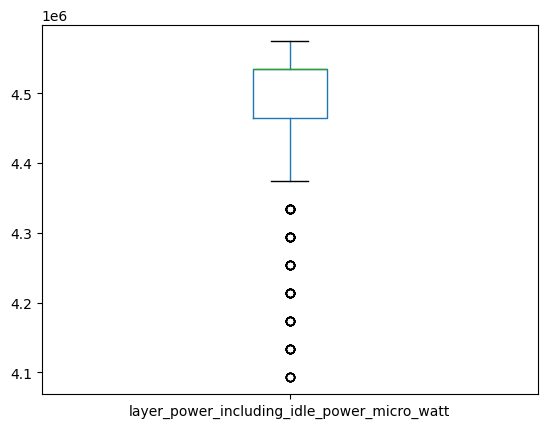

In [10]:
metrics_df_k1.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 2 Stride 1 Output 3

In [11]:
model_name = 'conv_k2_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 33.22it/s]


In [12]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k2_s1_o3: 12344
Number of TensorRT layers in conv_k2_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.778715 seconds


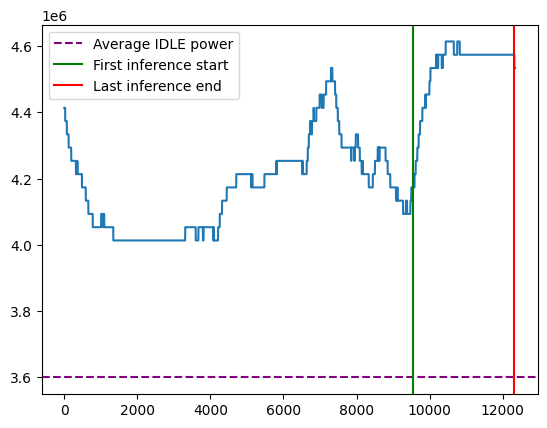

In [13]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[len(latency_data)-1][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [14]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k2 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 817072.21it/s]


In [15]:
metrics_df_k2.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,7.800000e+02,7.800000e+02,3000.000000
mean,1500.500000,4.541255e+06,9.429185e+05,0.351823
std,866.169729,9.076721e+04,9.076721e+04,0.003323
min,1.000000,4.173312e+06,5.749757e+05,0.326368
25%,750.750000,4.574592e+06,9.762557e+05,0.350880
50%,1500.500000,4.574592e+06,9.762557e+05,0.351616
75%,2250.250000,4.574592e+06,9.762557e+05,0.352384
max,3000.000000,4.614720e+06,1.016384e+06,0.426560


In [16]:
metrics_df_k2.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     780
layer_power_excluding_idle_power_micro_watt     780
layer_run_time                                 3000
dtype: int64

<Axes: >

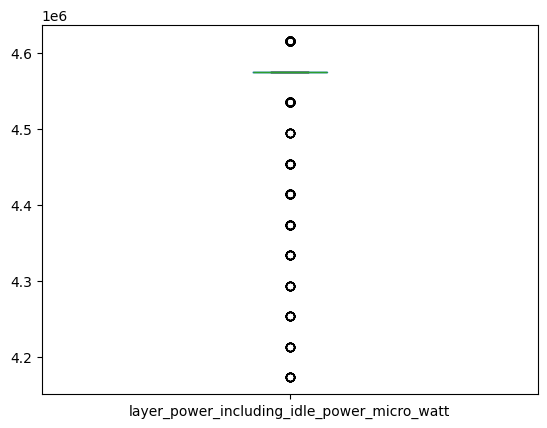

In [17]:
metrics_df_k2.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 3 Stride 1 Output 3

In [18]:
model_name = 'conv_k3_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 31.07it/s]


In [19]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k3_s1_o3: 13000
Number of TensorRT layers in conv_k3_s1_o3: 3
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 4.071866 seconds


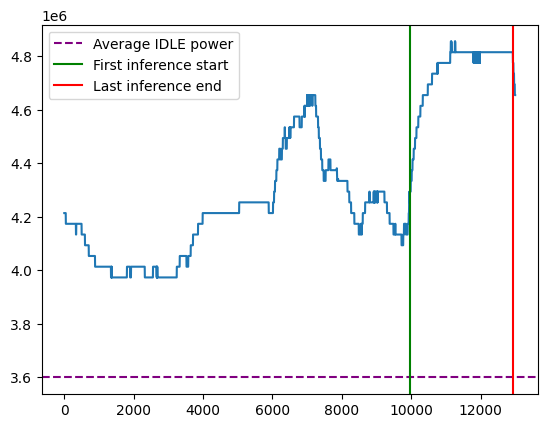

In [20]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[len(latency_data)-1][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [21]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k3 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9000/9000 [00:00<00:00, 863519.07it/s]


In [22]:
metrics_df_k3.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,9000.000000,1.037000e+03,1.037000e+03,9000.000000
mean,1500.500000,4.747139e+06,1.148802e+06,0.153941
std,866.073472,1.249812e+05,1.249812e+05,0.060402
min,1.000000,4.293696e+06,6.953597e+05,0.081856
25%,750.750000,4.735104e+06,1.136768e+06,0.083296
50%,1500.500000,4.815360e+06,1.217024e+06,0.150400
75%,2250.250000,4.815360e+06,1.217024e+06,0.227520
max,3000.000000,4.855488e+06,1.257152e+06,1.195104


In [23]:
metrics_df_k3.count()

cycle                                          9000
layer_power_including_idle_power_micro_watt    1037
layer_power_excluding_idle_power_micro_watt    1037
layer_run_time                                 9000
dtype: int64

<Axes: >

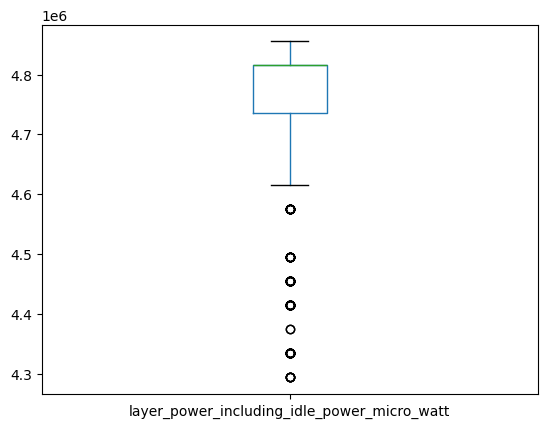

In [24]:
metrics_df_k3.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 4 Stride 1 Output 3

In [25]:
model_name = 'conv_k4_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 35.43it/s]


In [26]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k4_s1_o3: 12879
Number of TensorRT layers in conv_k4_s1_o3: 3
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 4.068741 seconds


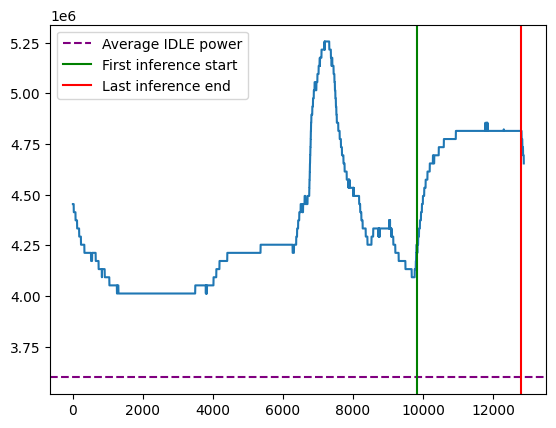

In [27]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[len(latency_data)-1][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [28]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k4 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9000/9000 [00:00<00:00, 681458.93it/s]


In [29]:
metrics_df_k4.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,9000.000000,8.760000e+02,8.760000e+02,9000.000000
mean,1500.500000,4.761186e+06,1.162850e+06,0.153985
std,866.073472,1.106961e+05,1.106961e+05,0.062587
min,1.000000,4.213440e+06,6.151037e+05,0.080000
25%,750.750000,4.775232e+06,1.176896e+06,0.081216
50%,1500.500000,4.815360e+06,1.217024e+06,0.148912
75%,2250.250000,4.815360e+06,1.217024e+06,0.230944
max,3000.000000,4.855488e+06,1.257152e+06,1.192864


In [30]:
metrics_df_k4.count()

cycle                                          9000
layer_power_including_idle_power_micro_watt     876
layer_power_excluding_idle_power_micro_watt     876
layer_run_time                                 9000
dtype: int64

<Axes: >

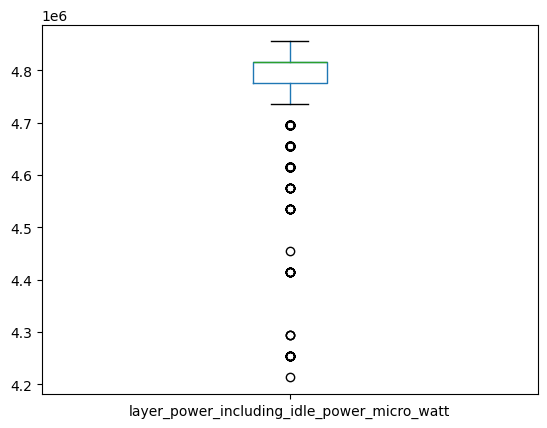

In [31]:
metrics_df_k4.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 5 Stride 1 Output 3

In [32]:
model_name = 'conv_k5_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 16.56it/s]


In [33]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k5_s1_o3: 13910
Number of TensorRT layers in conv_k5_s1_o3: 3
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 4.533414 seconds


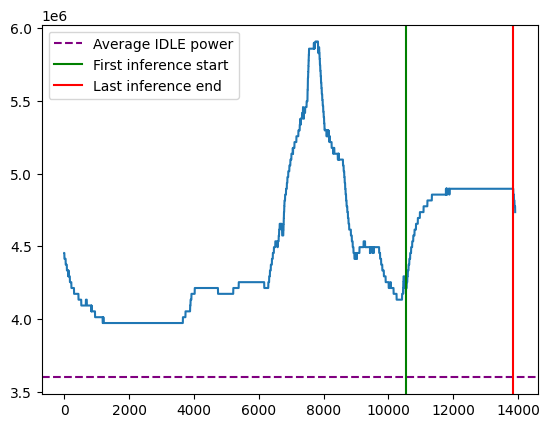

In [34]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[len(latency_data)-1][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [35]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k5 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9000/9000 [00:00<00:00, 824514.25it/s]


In [36]:
metrics_df_k5.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,9000.000000,1.305000e+03,1.305000e+03,9000.000000
mean,1500.500000,4.827660e+06,1.229323e+06,0.202531
std,866.073472,1.389959e+05,1.389959e+05,0.127451
min,1.000000,4.173312e+06,5.749757e+05,0.080480
25%,750.750000,4.855488e+06,1.257152e+06,0.081760
50%,1500.500000,4.895616e+06,1.297280e+06,0.151872
75%,2250.250000,4.895616e+06,1.297280e+06,0.372360
max,3000.000000,4.895616e+06,1.297280e+06,2.739488


In [37]:
metrics_df_k5.count()

cycle                                          9000
layer_power_including_idle_power_micro_watt    1305
layer_power_excluding_idle_power_micro_watt    1305
layer_run_time                                 9000
dtype: int64

<Axes: >

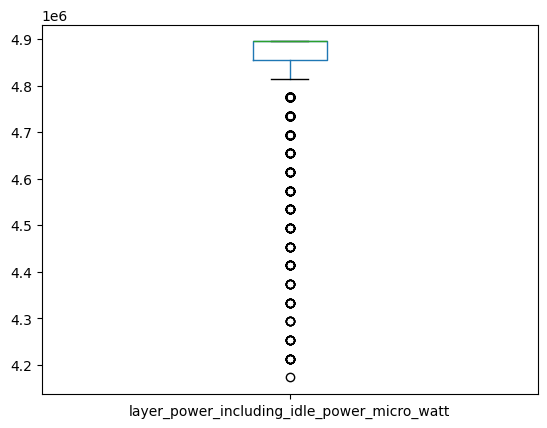

In [38]:
metrics_df_k5.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

## Kernels Plot

Text(0.5, 0, 'Kernel size')

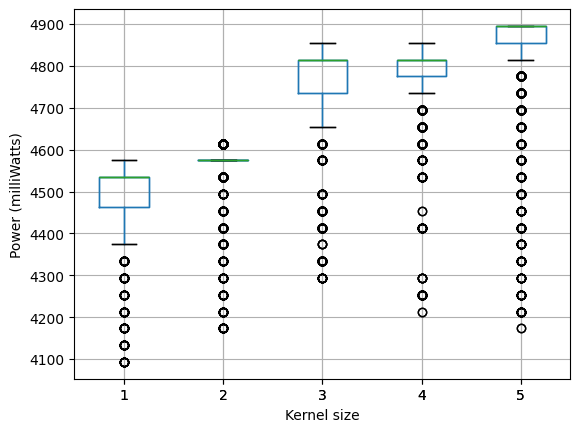

In [39]:
df = pd.concat(
    [
        metrics_df_k1["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k2["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k3["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k4["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k5["layer_power_including_idle_power_micro_watt"] * 1e-3,
    ],
    axis=1,
)


# set column names (will be displayed as plot labels)
df.columns = ['1', '2', '3', '4', '5']  

# use pandas' boxplot method
df.boxplot().set_ylabel('Power (milliWatts)')
df.boxplot().set_xlabel('Kernel size')